# Data Handling & Visualization with Pandas

## Dataset

In [24]:
import pandas as pd

df = pd.read_csv("D:/CitrusBits/pythonic-rebirth/datasets/car-sales.csv")
df

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,$4000.00
1,Honda,Red,87899,4,$5000.00
2,Toyota,Blue,32549,3,$7000.00
3,BMW,Black,11179,5,$22000.00
4,Nissan,White,213095,4,$3500.00
5,Toyota,Green,99213,4,$4500.00
6,Honda,Blue,45698,4,$7500.00
7,Honda,Blue,54738,4,$7000.00
8,Toyota,White,60000,4,$6250.00
9,Nissan,White,31600,4,$9700.00


## Code Problems

**Q: Basic Pandas Operations
Import pandas and create Series and DataFrames manually.
Import CSV files using pd.read_csv().
Export a DataFrame using to_csv().**


By default, pandas includes the DataFrame's index as extra column when writing to CSV. index=False tells it not to include that index column in output file.

In [25]:
import pandas as pd

# Creating a simple Series
series_s = pd.Series([10, 20, 30, 40, 50])
print(series_s)

print()

s = pd.Series([4000, 5000, 7000], index=["Toyota", "Honda", "BMW"])
print(s)

# dataframe is like a  2D Table
data = {
    "Make": ["Toyota", "Honda", "BMW"],
    "Colour": ["White", "Red", "Black"],
    "Odometer (KM)": [150043, 87899, 11179],
    "Doors": [4, 4, 5],
    "Price": [4000, 5000, 22000]
}

df = pd.DataFrame(data)
print(df)

print()

## importing csv files

# df.head()
# print()
#

print(df.tail())
#
# df.shape  # (rows, columns)
# print()
#
# df.columns  # column names
# print()
# df.info()  # summary of dataset
# print()

# index=False as it prevents Pandas from saving the extra index column.
df.to_csv("D:/CitrusBits/pythonic-rebirth/outputs/car-sales-outputs.csv", index=False);

0    10
1    20
2    30
3    40
4    50
dtype: int64

Toyota    4000
Honda     5000
BMW       7000
dtype: int64
     Make Colour  Odometer (KM)  Doors  Price
0  Toyota  White         150043      4   4000
1   Honda    Red          87899      4   5000
2     BMW  Black          11179      5  22000

     Make Colour  Odometer (KM)  Doors  Price
0  Toyota  White         150043      4   4000
1   Honda    Red          87899      4   5000
2     BMW  Black          11179      5  22000


In [26]:
df

,Make,Colour,Odometer (KM),Doors,Price
0,Toyota,White,150043,4,4000
1,Honda,Red,87899,4,5000
2,BMW,Black,11179,5,22000


**Q: Data Exploration
Use .dtypes, .info(), .describe(), .columns, .head(), .tail(), and len()
Access rows using .loc[] and .iloc[].
Practice slicing and filtering.**


.loc[]:
* label-based indexing
* selects data using labels
* df.loc[0:2] will get 0,1,2 i.e inclusive of 2
* df.loc[0:2, ['Make', 'Price']] rows 0-2 and only get make price cols

.iloc[]:
* integer position based indexing
* Selects data using integer positions, like standard Python list slicing
* df.iloc[0:2] will get only 0 and 1 rows (exclusive of 2)
* df.iloc[0:2, 0:3] will get 0-1 rows and 0-2 cols



In [27]:
print("Data types:")
print(df.dtypes)
print()

# summary (index, columns, non-null counts, dtypes, memory usage)
print("Info:")
df.info()
print()

# 3. Statistical summary (count, mean, std, min, max, etc. for numeric columns)
print("Describe:")
print(df.describe())
print()

# Column names
print("Columns:")
print(df.columns)
print()

# First 5 rows
print("Head:")
print(df.head())
print()

# Last 5 rows
print("Tail:")
print(df.tail())
print()

# Number of rows
print("Length:", len(df))
print()

# .loc[] -> label-based indexing
print("Row with label 0 (loc):")
print(df.loc[0])
print()

print("Rows 0 to 2, only 'Make' and 'Price' columns (loc):")
print(df.loc[0:2, ['Make', 'Price']])
print()

# .iloc[] -> position-based indexing
print("First row (iloc):")
print(df.iloc[0])
print()

print("Rows 0-2, first 3 columns (iloc):")
print(df.iloc[0:3, 0:3])
print()

print("Slice: rows 2 to 5:")
print(df[2:6])
print()

# now filtering
# cars with more than 4 doors
print("Cars with more than 4 doors:")
print(df[df['Doors'] > 4])
print()

# Toyota cars only
print("Toyota cars only:")
print(df[df['Make'] == 'Toyota'])
print()

# Cars with Odometer < 60000 AND Price > $5000
# (strip '$' and ',' from Price if it's stored as a string)
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)
filtered = df[(df['Odometer (KM)'] < 60000) & (df['Price'] > 5000)]
print("Odometer < 60000 and Price > 5000:")
print(filtered)

Data types:
Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price            int64
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Make           3 non-null      str  
 1   Colour         3 non-null      str  
 2   Odometer (KM)  3 non-null      int64
 3   Doors          3 non-null      int64
 4   Price          3 non-null      int64
dtypes: int64(3), str(2)
memory usage: 252.0 bytes

Describe:
       Odometer (KM)     Doors         Price
count       3.000000  3.000000      3.000000
mean    83040.333333  4.333333  10333.333333
std     69559.381864  0.577350  10115.993937
min     11179.000000  4.000000   4000.000000
25%     49539.000000  4.000000   4500.000000
50%     87899.000000  4.000000   5000.000000
75%    118971.000000  4.500000  13500.000000
max    150043.000000  5.000000  22000.000000

C

**Q: Series & Column Operations
Find the mean, sum, etc. of numeric Series.
Filter rows based on conditions.
Create new columns from existing ones.**


Regex
regex=True tells pandas to treat the pattern we passed as a regular expression (regex) instead of a literal string to match exactly.
Basically it will search for any of those symbols, if it is there, it will replace it by what we wrote, here " "

In [28]:
import pandas as pd

# Clean the Price column (remove $ and commas, convert to float)
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

# --- Mean, sum, etc. of numeric Series ---

print("Mean price:", df['Price'].mean())
print("Sum of prices:", df['Price'].sum())
print("Max odometer:", df['Odometer (KM)'].max())
print("Min odometer:", df['Odometer (KM)'].min())
print("Median price:", df['Price'].median())
print("Standard deviation of price:", df['Price'].std())
print("Count of doors column:", df['Doors'].count())
print()

# --- Filter rows based on conditions ---

# Cars priced above $6000
print("Cars priced above $6000:")
print(df[df['Price'] > 6000])
print()

# Cars with white colour
print("White cars:")
print(df[df['Colour'] == 'White'])
print()

# Cars with odometer less than 50000 and 4 doors
print("Low mileage 4-door cars:")
print(df[(df['Odometer (KM)'] < 50000) & (df['Doors'] == 4)])
print()

# --- Create new columns from existing ones ---

# Price per KM driven (value indicator)
df['Price_per_KM'] = df['Price'] / df['Odometer (KM)']

# Categorize mileage as High/Low
df['Mileage_Category'] = df['Odometer (KM)'].apply(lambda x: 'High' if x > 100000 else 'Low')

# Flag expensive cars (price above average)
avg_price = df['Price'].mean()
df['Above_Avg_Price'] = df['Price'] > avg_price

print("Dataframe with new columns:")
print(df)

Mean price: 10333.333333333334
Sum of prices: 31000.0
Max odometer: 150043
Min odometer: 11179
Median price: 5000.0
Standard deviation of price: 10115.99393699568
Count of doors column: 3

Cars priced above $6000:
  Make Colour  Odometer (KM)  Doors    Price
2  BMW  Black          11179      5  22000.0

White cars:
     Make Colour  Odometer (KM)  Doors   Price
0  Toyota  White         150043      4  4000.0

Low mileage 4-door cars:
Empty DataFrame
Columns: [Make, Colour, Odometer (KM), Doors, Price]
Index: []

Dataframe with new columns:
     Make Colour  Odometer (KM)  Doors    Price  Price_per_KM  \
0  Toyota  White         150043      4   4000.0      0.026659   
1   Honda    Red          87899      4   5000.0      0.056883   
2     BMW  Black          11179      5  22000.0      1.967976   

  Mileage_Category  Above_Avg_Price  
0             High            False  
1              Low            False  
2              Low             True  


**Q: Grouping & Aggregation
Use groupby() and mean() on the dataset.
Create a crosstab using pd.crosstab().**


In [29]:
# Clean the Price column (remove $ and commas, convert to float)
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

# --- groupby() and mean() ---

# Average price per Make
print("Average price by Make:")
print(df.groupby('Make')['Price'].mean())
print()

# Average odometer per Make
print("Average odometer by Make:")
print(df.groupby('Make')['Odometer (KM)'].mean())
print()

# Multiple aggregations at once (mean, sum, count) per Make
print("Multiple stats by Make:")
print(df.groupby('Make')['Price'].agg(['mean', 'sum', 'count']))
print()

# Group by multiple columns (Make and Colour)
print("Average price grouped by Make and Colour:")
print(df.groupby(['Make', 'Colour'])['Price'].mean())
print()

# Group by Make, aggregate multiple columns
print("Average price and odometer by Make:")
print(df.groupby('Make')[['Price', 'Odometer (KM)']].mean())
print()

# crosstab builds a frequency table

# Count of Make vs Doors
print("Crosstab: Make vs Doors:")
print(pd.crosstab(df['Make'], df['Doors']))
print()

# Count of Make vs Colour
print("Crosstab: Make vs Colour:")
print(pd.crosstab(df['Make'], df['Colour']))
print()

# Crosstab with margins (row/column totals)
print("Crosstab: Make vs Doors (with totals):")
print(pd.crosstab(df['Make'], df['Doors'], margins=True))

Average price by Make:
Make
BMW       22000.0
Honda      5000.0
Toyota     4000.0
Name: Price, dtype: float64

Average odometer by Make:
Make
BMW        11179.0
Honda      87899.0
Toyota    150043.0
Name: Odometer (KM), dtype: float64

Multiple stats by Make:
           mean      sum  count
Make                           
BMW     22000.0  22000.0      1
Honda    5000.0   5000.0      1
Toyota   4000.0   4000.0      1

Average price grouped by Make and Colour:
Make    Colour
BMW     Black     22000.0
Honda   Red        5000.0
Toyota  White      4000.0
Name: Price, dtype: float64

Average price and odometer by Make:
          Price  Odometer (KM)
Make                          
BMW     22000.0        11179.0
Honda    5000.0        87899.0
Toyota   4000.0       150043.0

Crosstab: Make vs Doors:
Doors   4  5
Make        
BMW     0  1
Honda   1  0
Toyota  1  0

Crosstab: Make vs Colour:
Colour  Black  Red  White
Make                     
BMW         1    0      0
Honda       0    1      0
To

**Q: Plotting and Visualization
Plot the Odometer (KM) using .plot() and .hist().
Fix and plot the Price column after cleaning.
Try different plot types (bar, line, scatter) with different columns.**


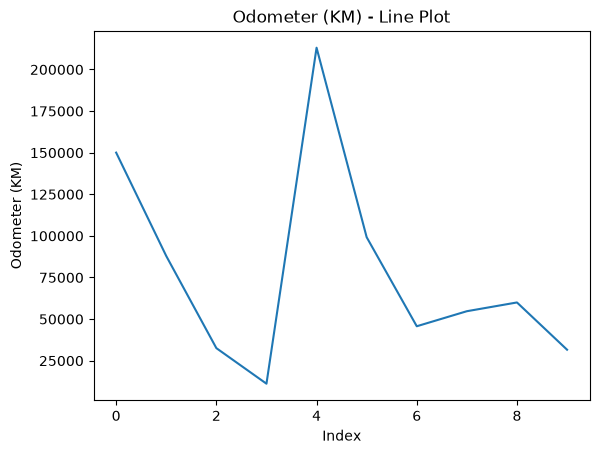

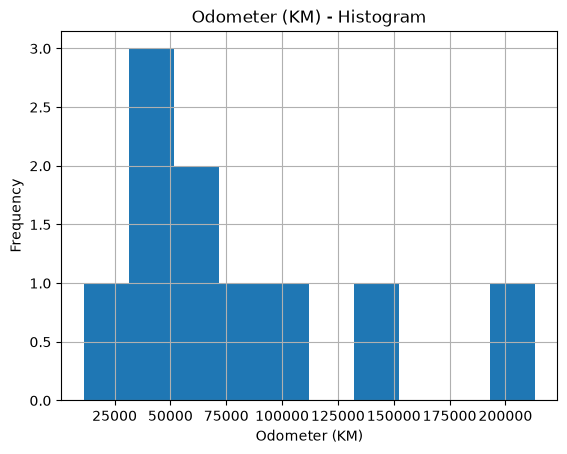

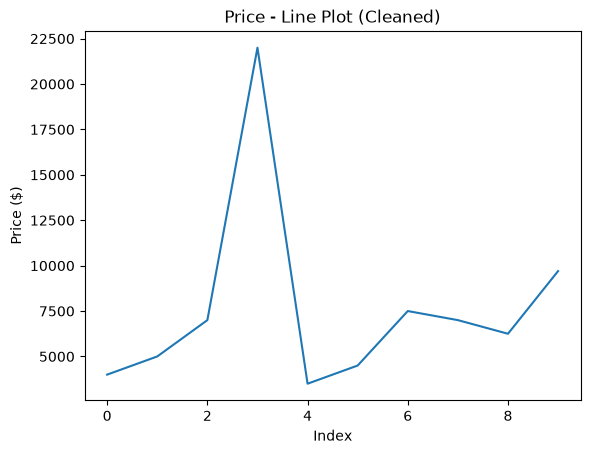

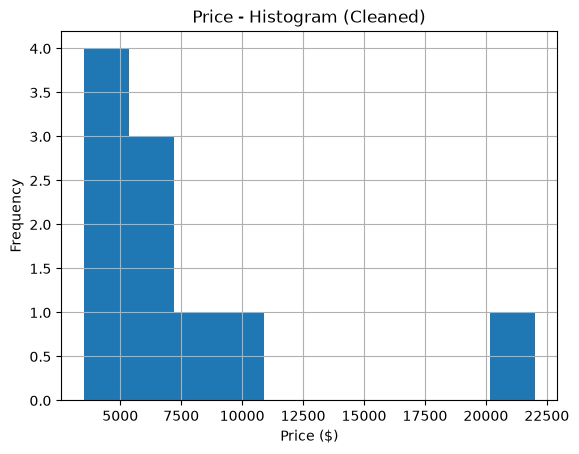

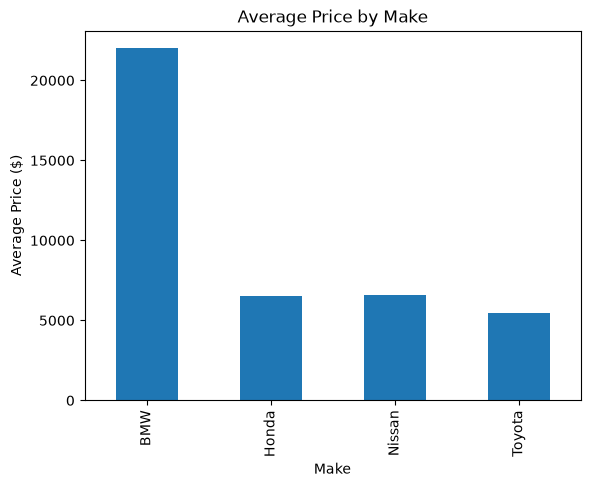

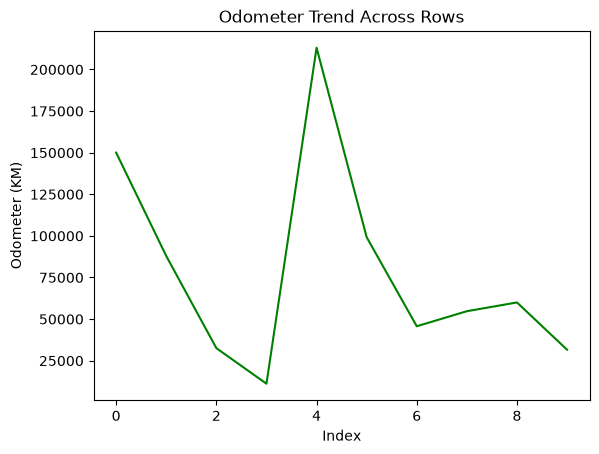

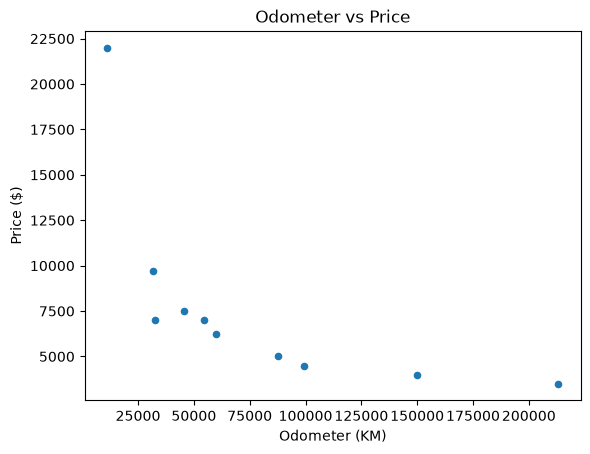

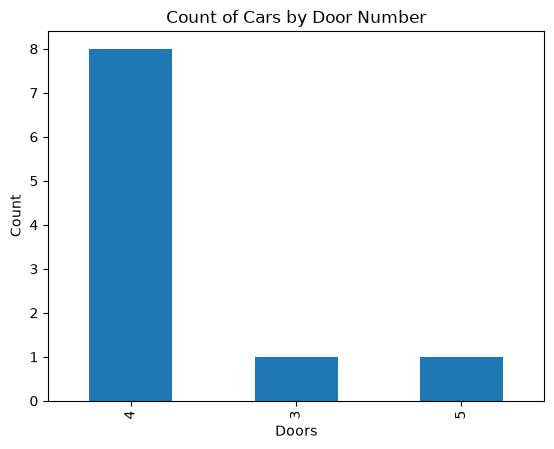

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('D:/CitrusBits/pythonic-rebirth/datasets/car-sales.csv')

# --- Plot Odometer (KM) using .plot() and .hist() ---

# Line plot of Odometer
df['Odometer (KM)'].plot()
plt.title('Odometer (KM) - Line Plot')
plt.xlabel('Index')
plt.ylabel('Odometer (KM)')
plt.show()

# Histogram of Odometer
df['Odometer (KM)'].hist()
plt.title('Odometer (KM) - Histogram')
plt.xlabel('Odometer (KM)')
plt.ylabel('Frequency')
plt.show()

# --- Fix and plot the Price column ---

# Clean Price column: remove $ and commas, convert to float
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

# Line plot of cleaned Price
df['Price'].plot()
plt.title('Price - Line Plot (Cleaned)')
plt.xlabel('Index')
plt.ylabel('Price ($)')
plt.show()

# Histogram of cleaned Price
df['Price'].hist()
plt.title('Price - Histogram (Cleaned)')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# --- Different plot types with different columns ---

# Bar plot: average price per Make
df.groupby('Make')['Price'].mean().plot(kind='bar')
plt.title('Average Price by Make')
plt.xlabel('Make')
plt.ylabel('Average Price ($)')
plt.show()

# Line plot: Odometer vs index for each row
df['Odometer (KM)'].plot(kind='line', color='green')
plt.title('Odometer Trend Across Rows')
plt.xlabel('Index')
plt.ylabel('Odometer (KM)')
plt.show()

# Scatter plot: Odometer vs Price
df.plot(kind='scatter', x='Odometer (KM)', y='Price')
plt.title('Odometer vs Price')
plt.xlabel('Odometer (KM)')
plt.ylabel('Price ($)')
plt.show()

# Bar plot: Doors count
df['Doors'].value_counts().plot(kind='bar')
plt.title('Count of Cars by Door Number')
plt.xlabel('Doors')
plt.ylabel('Count')
plt.show()

**Q: Data Cleaning
Clean and convert the Price column from string to integer.
Lowercase all values in the Make column.
Handle missing data using .fillna() and .dropna().**


In [31]:
import numpy as np

# --- Clean and convert Price column from string to integer ---

# Remove $ and commas, then convert to float first (handles decimals like $4000.00)
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

# Convert to integer (drops decimal part)
df['Price'] = df['Price'].astype(int)

print("Cleaned Price column:")
print(df['Price'])
print()

# --- Lowercase all values in the Make column ---

df['Make'] = df['Make'].str.lower()

print("Lowercased Make column:")
print(df['Make'])
print()

# Check for missing values first
print("Missing values per column:")
print(df.isna().sum())
print()

# Simulate some missing data for practice (optional, remove if your data already has NaNs)
df.loc[2, 'Colour'] = np.nan
df.loc[5, 'Odometer (KM)'] = np.nan

print("Data with missing values introduced:")
print(df)
print()

# fillna() - fill missing values
# Fill missing Colour with 'Unknown'
df['Colour'] = df['Colour'].fillna('Unknown')

# Fill missing Odometer with the column mean
df['Odometer (KM)'] = df['Odometer (KM)'].fillna(df['Odometer (KM)'].mean())

print("Data after fillna():")
print(df)
print()

# dropna() - drop rows with any missing values
df_dropped = df.dropna()

print("Data after dropna() (rows with any NaN removed):")
print(df_dropped)

Cleaned Price column:
0     4000
1     5000
2     7000
3    22000
4     3500
5     4500
6     7500
7     7000
8     6250
9     9700
Name: Price, dtype: int64

Lowercased Make column:
0    toyota
1     honda
2    toyota
3       bmw
4    nissan
5    toyota
6     honda
7     honda
8    toyota
9    nissan
Name: Make, dtype: str

Missing values per column:
Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

Data with missing values introduced:
     Make Colour  Odometer (KM)  Doors  Price
0  toyota  White       150043.0      4   4000
1   honda    Red        87899.0      4   5000
2  toyota    NaN        32549.0      3   7000
3     bmw  Black        11179.0      5  22000
4  nissan  White       213095.0      4   3500
5  toyota  Green            NaN      4   4500
6   honda   Blue        45698.0      4   7500
7   honda   Blue        54738.0      4   7000
8  toyota  White        60000.0      4   6250
9  nissan  White        31600.0      4  

**Q: Adding & Modifying Columns
Add columns like Seats, Engine Size, Price_per_KM.
Remove a column using .drop().**


In [32]:
# Load the dataset
df = pd.read_csv('D:/CitrusBits/pythonic-rebirth/datasets/car-sales.csv')

# Clean Price column first (needed for Price_per_KM)
df['Price'] = df['Price'].replace(r'[\$,]', '', regex=True).astype(float)

# --- Add new columns ---

# Seats column (manually assigned based on typical values, or a fixed default)
df['Seats'] = 5  # default value for all rows

# You can also assign different values based on Make
df.loc[df['Make'] == 'Toyota', 'Seats'] = 5
df.loc[df['Make'] == 'BMW', 'Seats'] = 4
df.loc[df['Make'] == 'Nissan', 'Seats'] = 5
df.loc[df['Make'] == 'Honda', 'Seats'] = 5

# Engine Size column (example values, can be customized)
engine_sizes = [1.8, 2.0, 1.6, 3.0, 1.5, 1.8, 2.0, 2.0, 1.8, 1.5]
df['Engine_Size'] = engine_sizes

# Price_per_KM column (value indicator)
df['Price_per_KM'] = df['Price'] / df['Odometer (KM)']

print("Dataframe with new columns:")
print(df)
print()

#Modify existing columns

# Round Price_per_KM to 4 decimal places
df['Price_per_KM'] = df['Price_per_KM'].round(4)

# Convert Engine_Size to a categorical label
df['Engine_Category'] = df['Engine_Size'].apply(lambda x: 'Large' if x >= 2.0 else 'Small')

print("Dataframe after modifying columns:")
print(df)
print()

# Remove a column using .drop()

# Drop Engine_Category (axis=1 means column, not row)
df = df.drop('Engine_Category', axis=1)

print("Dataframe after dropping Engine_Category:")
print(df)
print()

# Drop multiple columns at once
df_reduced = df.drop(['Seats', 'Engine_Size'], axis=1)

print("Dataframe after dropping Seats and Engine_Size:")
print(df_reduced)

Dataframe with new columns:
     Make Colour  Odometer (KM)  Doors    Price  Seats  Engine_Size  \
0  Toyota  White         150043      4   4000.0      5          1.8   
1   Honda    Red          87899      4   5000.0      5          2.0   
2  Toyota   Blue          32549      3   7000.0      5          1.6   
3     BMW  Black          11179      5  22000.0      4          3.0   
4  Nissan  White         213095      4   3500.0      5          1.5   
5  Toyota  Green          99213      4   4500.0      5          1.8   
6   Honda   Blue          45698      4   7500.0      5          2.0   
7   Honda   Blue          54738      4   7000.0      5          2.0   
8  Toyota  White          60000      4   6250.0      5          1.8   
9  Nissan  White          31600      4   9700.0      5          1.5   

   Price_per_KM  
0      0.026659  
1      0.056883  
2      0.215060  
3      1.967976  
4      0.016425  
5      0.045357  
6      0.164121  
7      0.127882  
8      0.104167  
9      0.3

**Q: Shuffle & Transform
Shuffle rows using .sample(frac=1).
Reset index using .reset_index().
Convert Odometer values to miles using .apply() and rename the column.**


In [33]:
# Shuffle rows using .sample(frac=1) ---

# frac=1 means return 100% of rows, but in random order
# returns a random shuffle of all the rows in DataFrame.
df_shuffled = df.sample(frac=1)

print("Shuffled dataframe:")
print(df_shuffled)
print()

# Reset index using .reset_index()
# this is needed after shuffling

# Without drop=True, the old index becomes a new column
df_shuffled_reset = df_shuffled.reset_index(drop=True)

print("Shuffled dataframe with reset index:")
print(df_shuffled_reset)
print()

# Convert Odometer values to miles using .apply() and rename ---
df_shuffled_reset['Odometer (KM)'] = df_shuffled_reset['Odometer (KM)'].apply(lambda x: x * 0.621371)

# Rename the column to reflect the new unit
df_shuffled_reset = df_shuffled_reset.rename(columns={'Odometer (KM)': 'Odometer (Miles)'})

print("Dataframe with Odometer converted to miles:")
print(df_shuffled_reset)

Shuffled dataframe:
     Make Colour  Odometer (KM)  Doors    Price  Seats  Engine_Size  \
6   Honda   Blue          45698      4   7500.0      5          2.0   
4  Nissan  White         213095      4   3500.0      5          1.5   
9  Nissan  White          31600      4   9700.0      5          1.5   
2  Toyota   Blue          32549      3   7000.0      5          1.6   
0  Toyota  White         150043      4   4000.0      5          1.8   
1   Honda    Red          87899      4   5000.0      5          2.0   
8  Toyota  White          60000      4   6250.0      5          1.8   
5  Toyota  Green          99213      4   4500.0      5          1.8   
3     BMW  Black          11179      5  22000.0      4          3.0   
7   Honda   Blue          54738      4   7000.0      5          2.0   

   Price_per_KM  
6        0.1641  
4        0.0164  
9        0.3070  
2        0.2151  
0        0.0267  
1        0.0569  
8        0.1042  
5        0.0454  
3        1.9680  
7        0.1279  
